<a href="https://colab.research.google.com/github/barney-rai/asl-recognition/blob/main/ASL_Final_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn

from tqdm import tqdm
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

In [3]:
#Check GPU, in Colab should be cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [4]:
#import ASL images
from google.colab import drive

drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/ASL_Project"

print(os.listdir(BASE_DIR), len(BASE_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['A', 'B', 'E', 'F', 'D', 'C', 'G', 'H', 'M', 'N', 'L', 'J', 'K', 'I', 'Q', 'S', 'P', 'T', 'R', 'U', 'O', 'nothing', 'Z', 'X', 'space', 'W', 'del', 'V', 'Y', 'asl_weights.pth'] 34


In [5]:
#class names
classes = sorted([
    folder
    for folder in os.listdir(BASE_DIR)
    if os.path.isdir(os.path.join(BASE_DIR, folder))
])

print(classes)
print("Number of classes:", len(classes))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Number of classes: 29


In [6]:
#a =0, b=1...z=25
class_to_idx = {
    class_name: i
    for i, class_name in enumerate(classes)
}

print(class_to_idx)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25, 'del': 26, 'nothing': 27, 'space': 28}


In [7]:
images = []
labels = []

In [8]:
#process all images (grayscale, resize, store image and label)
for class_name in classes:

    class_dir = os.path.join(BASE_DIR, class_name)
    label = class_to_idx[class_name]

    files = os.listdir(class_dir)

    print(f"\nProcessing {class_name}: {len(files)} images")

    for filename in tqdm(files):

        image_path = os.path.join(class_dir, filename)

        img = cv2.imread(image_path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        resized = cv2.resize(gray, (64, 64))

        images.append(resized)
        labels.append(label)


Processing A: 3000 images


100%|██████████| 3000/3000 [00:09<00:00, 306.66it/s]



Processing B: 3000 images


100%|██████████| 3000/3000 [00:10<00:00, 296.31it/s]



Processing C: 3000 images


...

100%|██████████| 3000/3000 [01:02<00:00, 47.67it/s] 



Processing nothing: 3000 images


100%|██████████| 3000/3000 [01:01<00:00, 49.10it/s] 



Processing space: 3000 images


100%|██████████| 3000/3000 [01:06<00:00, 45.40it/s] 


In [9]:
#x = images and y= labels
X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (87090, 64, 64)
y shape: (87090,)


In [10]:
#Normalize
X = X.astype(np.float32) / 255.0
print("Minimum:", X.min())
print("Maximum:", X.max())

Minimum: 0.0
Maximum: 1.0


In [11]:
#converting numpy to pytorch tensor
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

print("X:", X_tensor.shape)
print("y:", y_tensor.shape)

X: torch.Size([87090, 64, 64])
y: torch.Size([87090])


In [12]:
#connects correct image(X) with correct label(y)
dataset = TensorDataset(X_tensor, y_tensor)

print("Total images:", len(dataset))

Total images: 87090


In [13]:
#80/20 split for model eval
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Training images: 69672
Validation images: 17418


In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
class ASLCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [16]:
model = ASLCNN(num_classes=29)

model = model.to(device)

print(model)

ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=29, bias=True)
  )
)


In [17]:
#prediton + label = loss
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [18]:
#tests
#test batch
images, labels = next(iter(train_loader))

images = images.unsqueeze(1)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

#loss check
loss = criterion(outputs, labels)

print("Loss:", loss.item())

#test backprop
optimizer.zero_grad()

loss.backward()

optimizer.step()

print("Training step successful!")


Input shape: torch.Size([32, 1, 64, 64])
Output shape: torch.Size([32, 29])
Loss: 3.362988233566284
Training step successful!


In [20]:
# These store one result from each epoch
train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 10

for epoch in range(num_epochs):

    # -------------------
    # Training
    # -------------------
    model.train()

    total_train_loss = 0

    for images, labels in train_loader:

        images = images.unsqueeze(1)

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # Validation

    model.eval()

    total_val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.unsqueeze(1)

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_val_loss = total_val_loss / len(val_loader)

    accuracy = 100 * correct / total


    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Accuracy: {accuracy:.2f}%"
    )

Epoch 1/10 | Train Loss: 1.2691 | Val Loss: 0.5262 | Val Accuracy: 84.73%
Epoch 2/10 | Train Loss: 0.3776 | Val Loss: 0.2464 | Val Accuracy: 92.75%
Epoch 3/10 | Train Loss: 0.2004 | Val Loss: 0.1926 | Val Accuracy: 93.95%
Epoch 4/10 | Train Loss: 0.1317 | Val Loss: 0.1128 | Val Accuracy: 96.73%
Epoch 5/10 | Train Loss: 0.0952 | Val Loss: 0.1073 | Val Accuracy: 96.45%
Epoch 6/10 | Train Loss: 0.0773 | Val Loss: 0.0850 | Val Accuracy: 97.34%
Epoch 7/10 | Train Loss: 0.0620 | Val Loss: 0.1000 | Val Accuracy: 97.13%
Epoch 8/10 | Train Loss: 0.0527 | Val Loss: 0.0857 | Val Accuracy: 97.50%
Epoch 9/10 | Train Loss: 0.0462 | Val Loss: 0.0512 | Val Accuracy: 98.52%
Epoch 10/10 | Train Loss: 0.0399 | Val Loss: 0.0611 | Val Accuracy: 98.16%


In [21]:
print(model)
print(type(model))

ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=29, bias=True)
  )
)
<class '__main__.ASLCNN'>


In [22]:
torch.save(model.state_dict(),"asl_weights.pth")

In [23]:
import os

print(os.path.exists("asl_weights.pth"))
print(os.path.getsize("asl_weights.pth"))

True
1979269


In [24]:
import shutil

shutil.copy(
    "asl_weights.pth",
    "/content/drive/MyDrive/ASL_Project/asl_weights.pth"
)

'/content/drive/MyDrive/ASL_Project/asl_weights.pth'

In [25]:
import os

print(
    os.path.exists(
        "/content/drive/MyDrive/ASL_Project/asl_weights.pth"
    )
)

True


In [29]:
model_loaded = ASLCNN(num_classes=29)

In [27]:
model_loaded.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/ASL_Project/asl_weights.pth",
        map_location=device
    )
)

<All keys matched successfully>

In [28]:
model_loaded = model_loaded.to(device)

In [30]:
model_loaded.eval()

ASLCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=29, bias=True)
  )
)

In [33]:
image, label = val_dataset[0]

image = image.unsqueeze(0).unsqueeze(0)
image = image.to(device)

model.eval()

with torch.no_grad():
    output = model(image)

prediction = output.argmax(dim=1).item()

print("Actual class:", label.item())
print("Predicted class:", prediction)
print("Actual gesture:", classes[label.item()])
print("Predicted gesture:", classes[prediction])

Actual class: 27
Predicted class: 27
Actual gesture: nothing
Predicted gesture: nothing


In [34]:
#calculate validation accuracy on untrained images
correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.unsqueeze(1)

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print("Correct:", correct)
print("Total:", total)
print(f"Validation Accuracy: {accuracy:.2f}%")

Correct: 17097
Total: 17418
Validation Accuracy: 98.16%


In [35]:
all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.unsqueeze(1)

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())


In [36]:
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
print("Predictions:", all_predictions.shape)
print("Labels:", all_labels.shape)

Predictions: (17418,)
Labels: (17418,)


In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

[[570   2   2   4   2   5   0   0   2   0   0   0   6   0   2   0   0   0
    3   1   0   0   1   0   1   0   1   0   0]
 [  0 586   0   3   8   2   1   0   0   0   0   0   2   0   0   0   0   0
    0   0   0   0   4   0   0   0   0   0   0]
 [  0   0 586   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0 585   3   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  5   3   0   5 604   1   2   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   2   0 640   0   0   3   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 634   3   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   1]
 [  0   0   0   0   0   0  11 601   0   1   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   

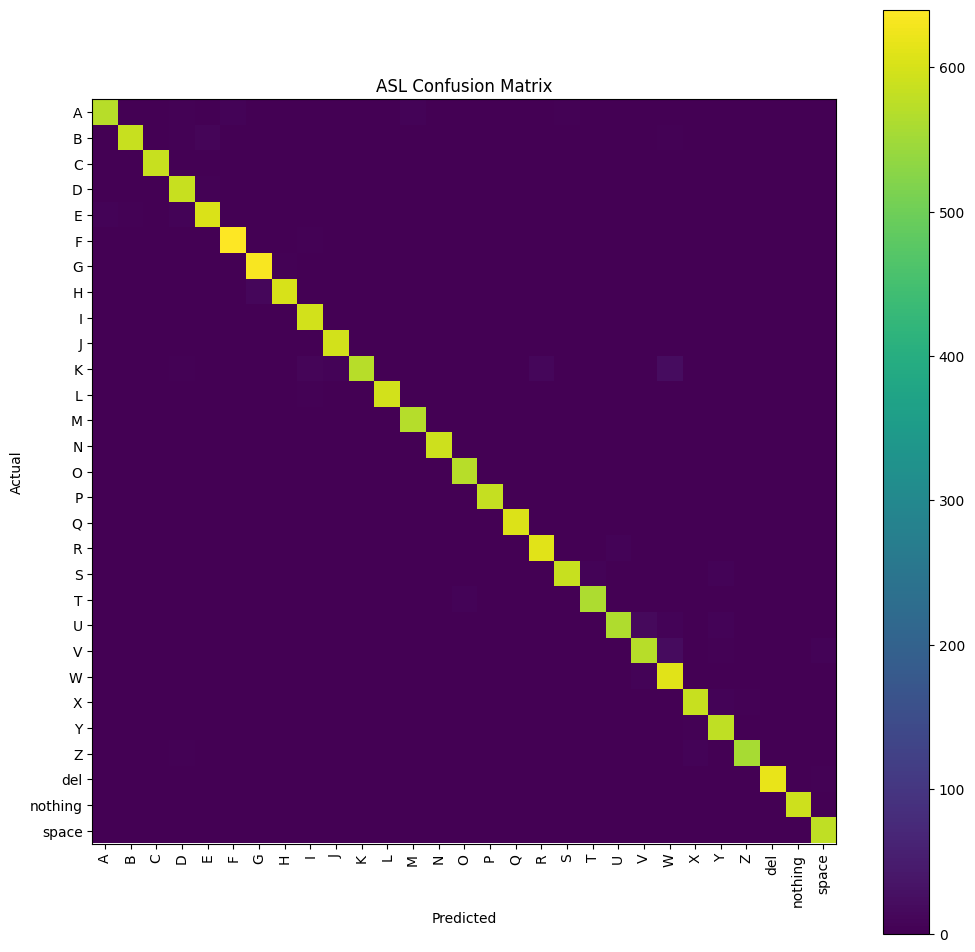

In [38]:
#note 8/29 - E has a 86 percent accuary, which is lowest
#difficulty distinguishing certain visually similar gestures, particularly E, U, V, H, M, and Y. Check Cell 37
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))

plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ASL Confusion Matrix")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=90
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.show()

In [39]:
for i, class_name in enumerate(classes):

    class_total = np.sum(all_labels == i)

    class_correct = np.sum(
        (all_labels == i) &
        (all_predictions == i)
    )

    class_accuracy = 100 * class_correct / class_total

    print(
        f"{class_name}: "
        f"{class_accuracy:.2f}%"
    )

A: 94.68%
B: 96.70%
C: 100.00%
D: 99.49%
E: 97.11%
F: 99.22%
G: 99.37%
H: 97.88%
I: 99.83%
J: 99.83%
K: 91.65%
L: 99.00%
M: 99.13%
N: 99.66%
O: 99.30%
P: 99.49%
Q: 99.84%
R: 98.55%
S: 97.18%
T: 97.91%
U: 94.30%
V: 94.85%
W: 98.87%
X: 98.48%
Y: 99.48%
Z: 97.54%
del: 98.88%
nothing: 100.00%
space: 98.63%


In [40]:
incorrect_indices = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect predictions:", len(incorrect_indices))

Incorrect predictions: 321


Actual: X
Predicted: Y


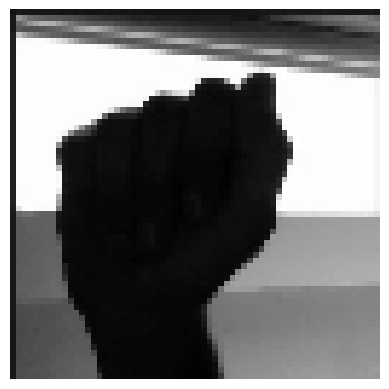

In [41]:
idx = incorrect_indices[0]

image = X[idx]

actual = classes[all_labels[idx]]
predicted = classes[all_predictions[idx]]

print("Actual:", actual)
print("Predicted:", predicted)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [42]:
#biggest miscalcs
confusions = []

for actual in range(len(classes)):
    for predicted in range(len(classes)):

        if actual != predicted:
            confusions.append(
                (
                    cm[actual, predicted],
                    classes[actual],
                    classes[predicted]
                )
            )

confusions.sort(reverse=True)

for count, actual, predicted in confusions[:15]:
    print(
        f"Actual {actual} → Predicted {predicted}: {count}"
    )

Actual K → Predicted W: 22
Actual V → Predicted W: 19
Actual U → Predicted V: 17
Actual K → Predicted R: 12
Actual H → Predicted G: 11
Actual K → Predicted I: 9
Actual B → Predicted E: 8
Actual V → Predicted space: 7
Actual U → Predicted W: 7
Actual T → Predicted O: 7
Actual W → Predicted V: 6
Actual S → Predicted T: 6
Actual K → Predicted J: 6
Actual A → Predicted M: 6
Actual Z → Predicted X: 5


In [43]:
weak_classes = ["E", "U", "M", "H", "V", "Y"]

for class_name in weak_classes:

    actual_idx = class_to_idx[class_name]

    print(f"\n--- {class_name} ---")

    mistakes = []

    for predicted_idx in range(len(classes)):

        if predicted_idx != actual_idx:

            count = cm[actual_idx, predicted_idx]

            if count > 0:
                mistakes.append(
                    (count, classes[predicted_idx])
                )

    mistakes.sort(reverse=True)

    for count, predicted in mistakes[:5]:
        print(
            f"{class_name} → {predicted}: {count}"
        )


--- E ---
E → D: 5
E → A: 5
E → B: 3
E → G: 2
E → V: 1

--- U ---
U → V: 17
U → W: 7
U → Y: 5
U → M: 2
U → space: 1

--- M ---
M → I: 2
M → O: 1
M → J: 1
M → D: 1

--- H ---
H → G: 11
H → Q: 1
H → J: 1

--- V ---
V → W: 19
V → space: 7
V → Y: 3
V → U: 2

--- Y ---
Y → X: 3


In [44]:
#finding the actual incorrect images
val_indices = val_dataset.indices

incorrect_val_positions = np.where(
    all_predictions != all_labels
)[0]

print("Incorrect validation images:", len(incorrect_val_positions))

Incorrect validation images: 321


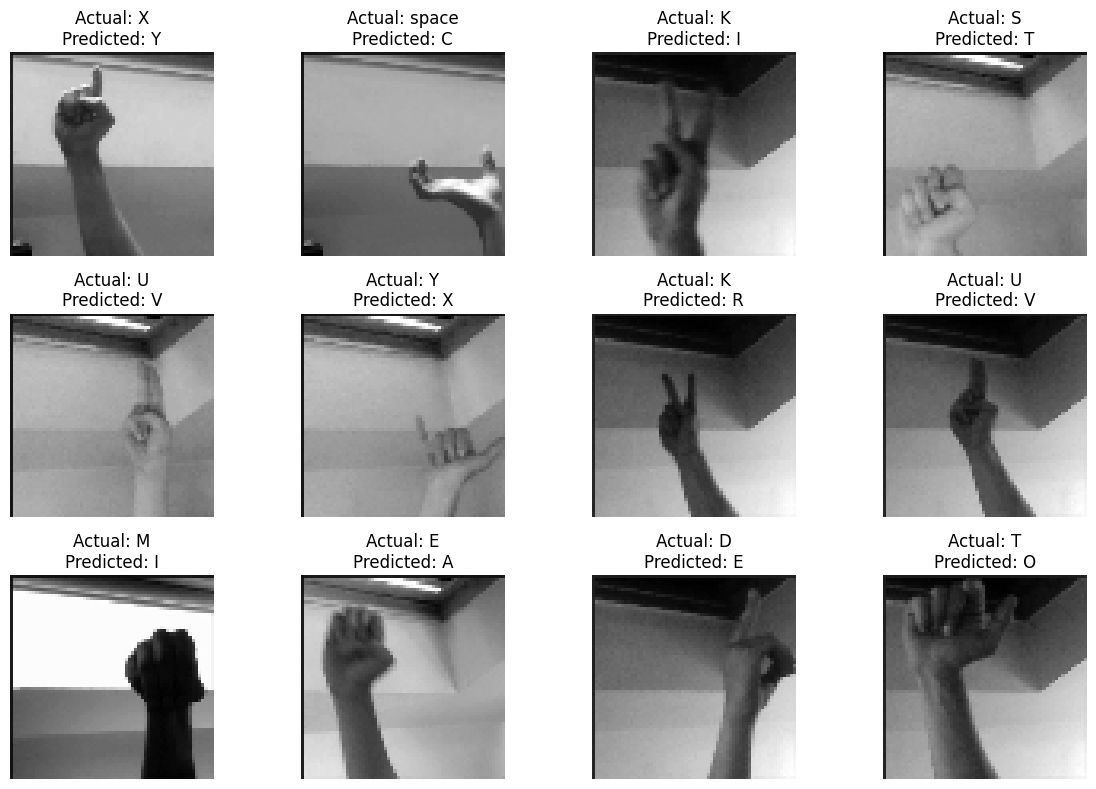

In [45]:
import matplotlib.pyplot as plt

num_images = min(12, len(incorrect_val_positions))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    val_position = incorrect_val_positions[i]

    original_index = val_indices[val_position]

    image = X[original_index]

    actual = classes[all_labels[val_position]]
    predicted = classes[all_predictions[val_position]]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image, cmap="gray")
    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Incorrect E predictions: 18


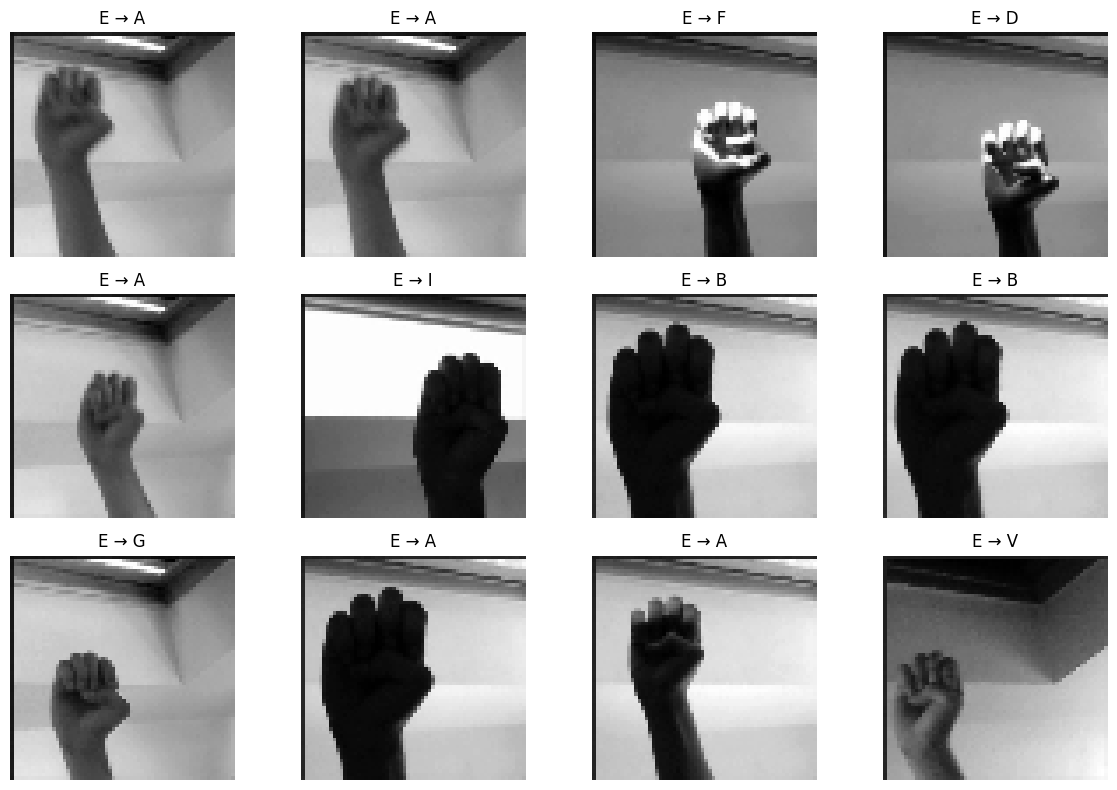

Correct E predictions: 604


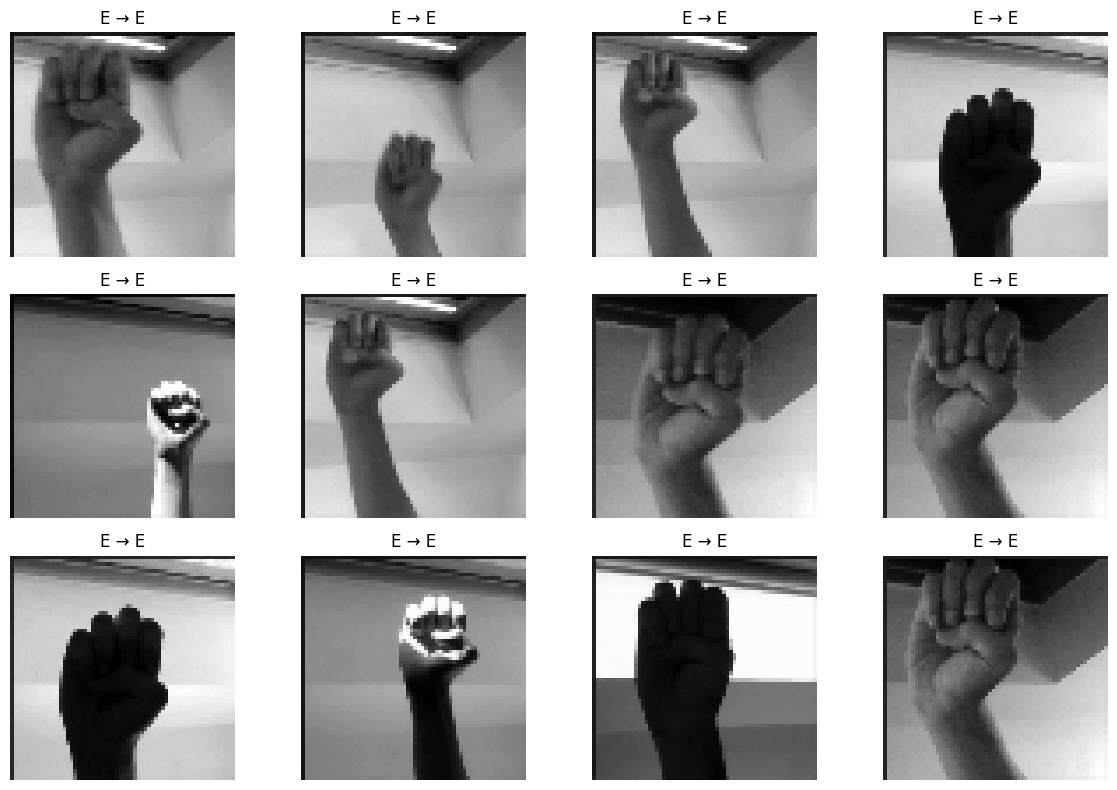

In [46]:
#Checking E specifically
e_idx = class_to_idx["E"]

e_mistakes = np.where(
    (all_labels == e_idx) &
    (all_predictions != e_idx)
)[0]

print("Incorrect E predictions:", len(e_mistakes))
num_images = min(12, len(e_mistakes))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    val_position = e_mistakes[i]

    original_index = val_indices[val_position]

    image = X[original_index]

    predicted = classes[all_predictions[val_position]]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image, cmap="gray")
    plt.title(f"E → {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Comparing correct Es
e_correct = np.where(
    (all_labels == e_idx) &
    (all_predictions == e_idx)
)[0]

print("Correct E predictions:", len(e_correct))
num_images = min(12, len(e_correct))

plt.figure(figsize=(12, 8))

for i in range(num_images):

    val_position = e_correct[i]

    original_index = val_indices[val_position]

    image = X[original_index]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image, cmap="gray")
    plt.title("E → E")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [47]:
#overall validation accuracy
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.unsqueeze(1)
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")
print(f"Correct: {correct}")
print(f"Total: {total}")

Validation Accuracy: 98.16%
Correct: 17097
Total: 17418


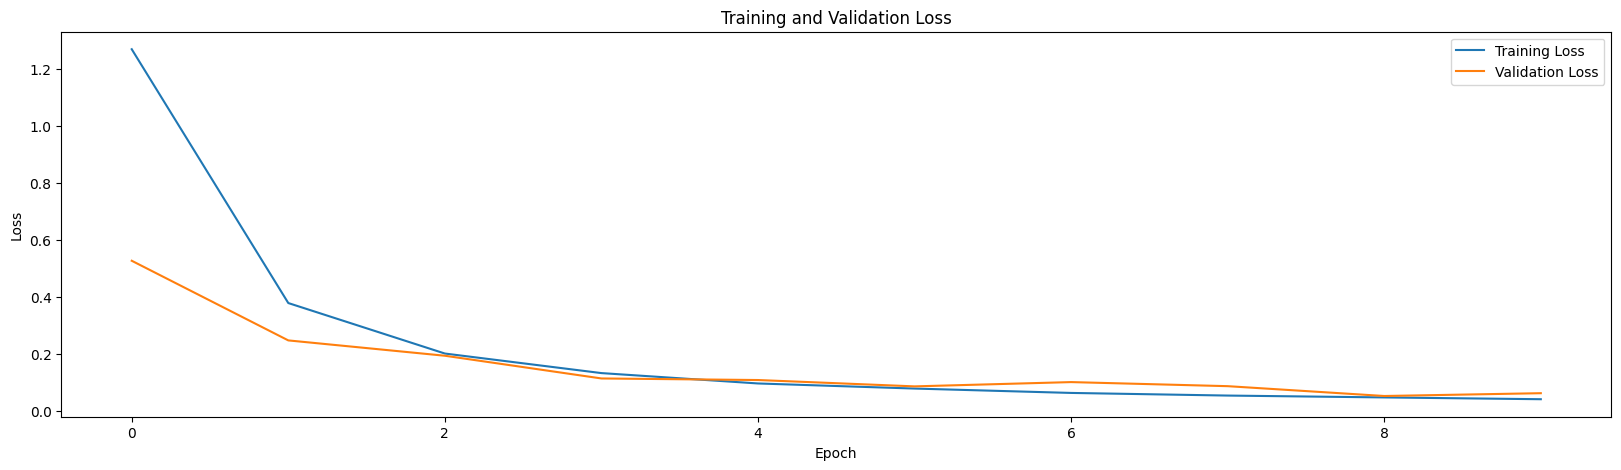

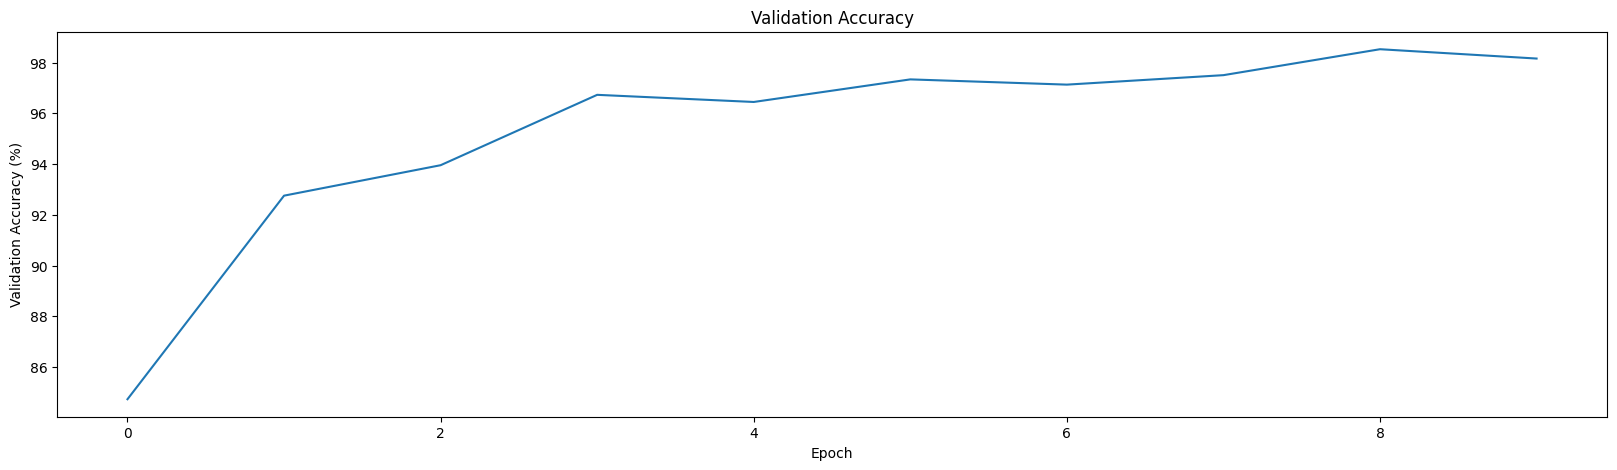

In [48]:
#checking for learning vs overfitting

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()
plt.figure(figsize=(20, 5))

plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy")

plt.show()

In [49]:
#prediction function
def predict_image(image):

    model.eval()

    tensor = torch.tensor(
        image,
        dtype=torch.float32
    )

    tensor = tensor.unsqueeze(0).unsqueeze(0)
    tensor = tensor.to(device)

    with torch.no_grad():
        outputs = model(tensor)

    prediction = outputs.argmax(dim=1).item()

    return classes[prediction]

prediction = predict_image(X[0])

print("Prediction:", prediction)

Prediction: A


In [50]:
#confidence
def predict_image(image):

    model.eval()

    tensor = torch.tensor(
        image,
        dtype=torch.float32
    )

    tensor = tensor.unsqueeze(0).unsqueeze(0)
    tensor = tensor.to(device)

    with torch.no_grad():
        outputs = model(tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = probabilities.max(dim=1)

    return (
        classes[prediction.item()],
        confidence.item()
    )


In [51]:
#YAYYYYY-Trained a CNN to classify 29 ASL gesture classes, achieving a peak validation accuracy of 98.52% across 10 epochs.
prediction, confidence = predict_image(X[0])

print("Prediction:", prediction)
print(f"Confidence: {confidence * 100:.2f}%")

Prediction: A
Confidence: 99.81%


In [52]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/ASL_Project/asl_cnn_final.pth"
)

In [53]:
import json

with open(
    "/content/drive/MyDrive/ASL_Project/classes.json",
    "w"
) as f:
    json.dump(classes, f)

In [54]:
import os

print(os.path.exists(
    "/content/drive/MyDrive/ASL_Project/asl_cnn_final.pth"
))

print(os.path.exists(
    "/content/drive/MyDrive/ASL_Project/classes.json"
))

True
True


In [ ]:
#moving on to webcam